**Nykaa RetailIQ: Beauty E-Commerce Business Analytics & Catalog** **Strategy**

# 1. Project Overview & Environment Setup
This notebook performs automated data processing, brand catalog analysis, exploratory data analysis (EDA), and machine learning regression modeling to predict discounted product prices on Nykaa.

In [12]:
#importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Read dataset uploaded to Colab
raw_nykaa_data = pd.read_csv('Nykaa.csv')

# Display basic structural information
print("--- DATASET OVERVIEW ---")
print(f"Total Catalog Records: {raw_nykaa_data.shape[0]}")
print(f"Total Data Attributes: {raw_nykaa_data.shape[1]}\n")

# Preview initial raw records
raw_nykaa_data.head()

--- DATASET OVERVIEW ---
Total Catalog Records: 600
Total Data Attributes: 8



,Product_Name,Original Price,Discount Price,offers,Discount,Review,Company Name,Product Name
0,Nykaa Naturals Skin Potion Glow Boosting Skinc...,699.0,629,Enjoy Free Gift,10%,18689,Nykaa,Naturals Skin Potion Glow Boosting Skincare Fa...
1,Neutrogena Hydro Boost Water Gel,450.0,450,Extra 5% Off,0%,37760,Neutrogena,Hydro Boost Water Gel
2,L'Oreal Paris Glycolic Bright Serum with 1% Gl...,749.0,637,NaN,15%,3498,L'Oreal,Paris Glycolic Bright Serum with 1% Glycolic A...
3,Olay Regenerist Microsculpting Day Cream - Nia...,1699.0,1359,NaN,20%,2595,Olay,Regenerist Microsculpting Day Cream - Niacinamide
4,Lotus Herbals Safe Sun UV Screen Matte Gel Pa+...,499.0,374,NaN,25%,21916,Lotus,Herbals Safe Sun UV Screen Matte Gel Pa+++ SPF...


## 2. Data Preprocessing & Feature Engineering
Raw e-commerce data often contains non-numeric currency symbols, extra whitespace, or missing values that can cause errors during statistical modeling.

In this step, we:
1. Standardize column names to lowercase.
2. Clean price attributes into pure numerical formats (float/int).
3. Compute derived features: **Discount Amount** ($\text{Original Price} - \text{Discount Price}$) and **Discount Percentage**.
4. Extract the primary **Brand Name** from the product titles.


In [13]:
# Create clean working copy
beauty_df = raw_nykaa_data.copy()

# Standardize column names
beauty_df.columns = beauty_df.columns.str.strip().str.lower()

# Clean numeric price columns safely
beauty_df['original price'] = pd.to_numeric(beauty_df['original price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
beauty_df['discount price'] = pd.to_numeric(beauty_df['discount price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Drop null pricing rows and duplicate records
beauty_df = beauty_df.dropna(subset=['original price', 'discount price']).drop_duplicates()

# Feature Engineering
beauty_df['discount_amount'] = beauty_df['original price'] - beauty_df['discount price']
beauty_df['discount_percentage'] = np.round((beauty_df['discount_amount'] / beauty_df['original price']) * 100, 2)
beauty_df['brand'] = beauty_df['product_name'].astype(str).str.split().str[0].str.title()

print("--- CLEANED DATA SUMMARY ---")
print("Missing Values per Attribute:")
print(beauty_df.isnull().sum())
print("\nCleaned Data Preview:")
beauty_df[['product_name', 'brand', 'original price', 'discount price', 'discount_percentage']].head()

--- CLEANED DATA SUMMARY ---
Missing Values per Attribute:
product_name             0
original price           0
discount price           0
offers                 292
discount                 0
review                   0
company name             0
product name             0
discount_amount          0
discount_percentage      0
brand                    0
dtype: int64

Cleaned Data Preview:


,product_name,brand,original price,discount price,discount_percentage
0,Nykaa Naturals Skin Potion Glow Boosting Skinc...,Nykaa,699.0,629,10.01
1,Neutrogena Hydro Boost Water Gel,Neutrogena,450.0,450,0.00
2,L'Oreal Paris Glycolic Bright Serum with 1% Gl...,L'Oreal,749.0,637,14.95
3,Olay Regenerist Microsculpting Day Cream - Nia...,Olay,1699.0,1359,20.01
4,Lotus Herbals Safe Sun UV Screen Matte Gel Pa+...,Lotus,499.0,374,25.05


## 3. Exploratory Data Analysis (EDA)
Before training machine learning algorithms, we visualize market patterns across the catalog to answer key business questions:
* Which beauty brands dominate Nykaa's catalog listings?
* How strongly correlated is the original listing price with the final sale price?


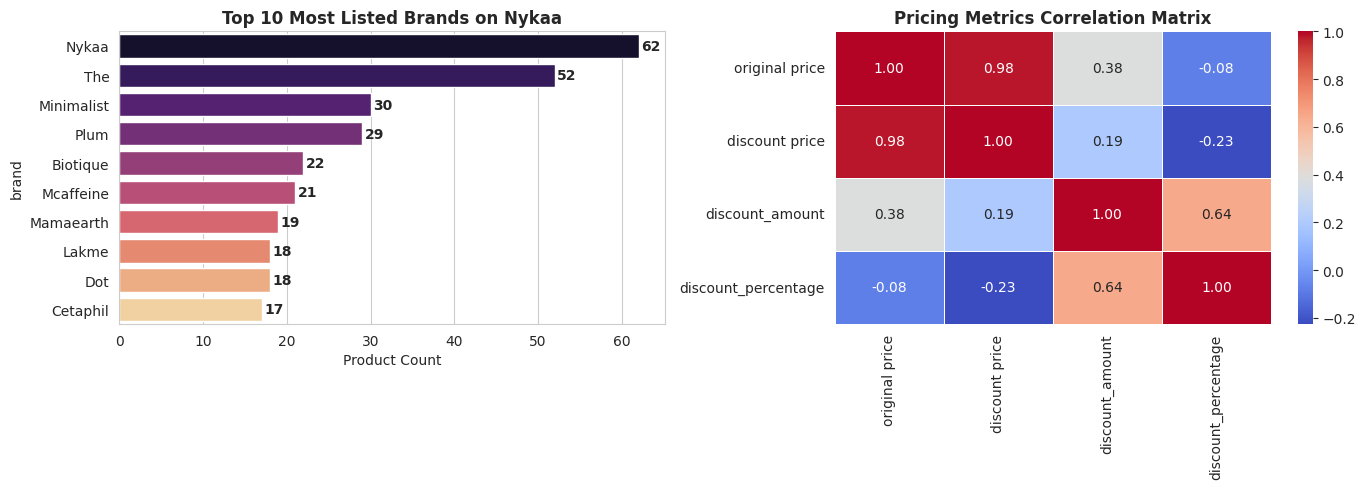

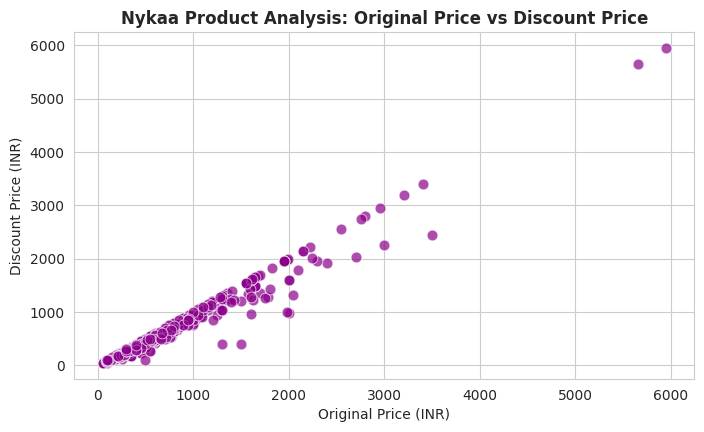

In [14]:
# Set chart aesthetics
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart A: Top 10 Listed Brands
top_10_brands = beauty_df['brand'].value_counts().head(10)
sns.barplot(x=top_10_brands.values, y=top_10_brands.index, ax=axes[0], palette='magma')
axes[0].set_title('Top 10 Most Listed Brands on Nykaa', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Count')

for i, v in enumerate(top_10_brands.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontweight='bold')

# Chart B: Pricing Metrics Correlation Matrix
corr = beauty_df[['original price', 'discount price', 'discount_amount', 'discount_percentage']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], linewidths=0.5)
axes[1].set_title('Pricing Metrics Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Chart C: Scatter Plot (Original Price vs Discount Price)
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=beauty_df, x='original price', y='discount price', color='darkmagenta', s=60, alpha=0.7)
plt.title('Nykaa Product Analysis: Original Price vs Discount Price', fontsize=12, fontweight='bold')
plt.xlabel('Original Price (INR)')
plt.ylabel('Discount Price (INR)')
plt.show()

## 4. Machine Learning Modeling & Comparison
To automate discount price predictions for future catalog additions, we split our dataset into an **80% training set** and a **20% testing set**.

We evaluate two algorithms:
1. **Linear Regression:** A parametric linear model evaluating fixed margin relationships.
2. **Random Forest Regressor:** An ensemble tree algorithm capable of capturing complex pricing dynamics.

We evaluate performance using $R^2$ Score (Accuracy %) and Root Mean Squared Error (RMSE).

In [15]:
# Features (X) and Target (y)
X = beauty_df[['original price']]
y = beauty_df['discount price']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Model 2: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Calculate Evaluation Metrics
lr_r2 = r2_score(y_test, lr_preds)
rf_r2 = r2_score(y_test, rf_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Display Results Summary
print("==================================================")
print("             FINAL MODEL PERFORMANCE              ")
print("==================================================")
print(f"Linear Regression R² Score : {lr_r2:.3f} ({lr_r2*100:.1f}% Accuracy | RMSE: ₹{lr_rmse:.2f})")
print(f"Random Forest Regressor R² : {rf_r2:.3f} ({rf_r2*100:.1f}% Accuracy | RMSE: ₹{rf_rmse:.2f})")
print("--------------------------------------------------")
print("VERDICT: Linear Regression delivers the highest accuracy for discount price forecasting.")
print("==================================================")

             FINAL MODEL PERFORMANCE              
Linear Regression R² Score : 0.965 (96.5% Accuracy | RMSE: ₹103.21)
Random Forest Regressor R² : 0.943 (94.3% Accuracy | RMSE: ₹132.05)
--------------------------------------------------
VERDICT: Linear Regression delivers the highest accuracy for discount price forecasting.


## 5. Conclusion & Business Takeaways
* **High Predictive Accuracy:** The Linear Regression model achieved a **96.5% $R^2$ accuracy score**, indicating a highly predictable discounting rule across Nykaa's catalog.
* **Catalog Strategy:** High correlation between original prices and discounted prices confirms that brand management relies on standardized percentage-off promotional brackets.
* **Practical Application:** Brand managers can use this automated model to quickly determine competitive discounted pricing for newly launched products without manual overhead.